# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vishal-141206/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Decision supported:** out of a large content portfolio, which pages should a content editor
review first, this week, given limited time. Not "is this page declining, yes/no" in isolation
— an editor works a sorted queue, not a set of binary flags.

**Unit of analysis:** one content item (one row = one `content_hash_id`, aggregated over a
calendar month of daily search performance).

**Output:** a ranked priority score per content item, with a reason code and an archetype
label (`URGENT_CTR_FIX`, `STANDARD_CTR_FIX`, `LOW_PRIORITY_WATCH`, `STABLE`).

**Action a human takes:** review the top of the queue, verify the flagged CTR gap in Google
Search Console directly, and — if it holds up — rewrite the page's title/meta/snippet to
better match what's already earning it real search visibility.

**Cost of a wrong call:** asymmetric, not symmetric. A false positive (flagging a page that
didn't need attention) wastes scarce editor time. A false negative (missing a real
underperformer) lets that page keep losing recoverable clicks, quieter but compounding. Given
this asymmetry, precision at the top of the ranking matters more than recall across the whole
list — which is why precision@20 is this project's primary evaluation metric throughout.

**Why data/ML helps at all:** a plain rule ("flag stale pages" or "flag low-position pages")
does not hold up against this portfolio's own data. A signal audit (Week 3, see §6) found
position tier alone doesn't cleanly separate decliners, staleness data in this warehouse
appears synthetic rather than editorial, and CTR's relationship with position and volume is
real but weak and unevenly distributed — exactly the kind of tangled, multi-signal pattern
that benefits from a scored, validated ranking approach rather than a single hand-written
if-statement.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank's pseudonymized ML internship warehouse (Hugging Face, gated release
`v20260703`), specifically `fact_content_daily_performance` (78,835,655 rows, report_date ×
client_hash_id × content_hash_id grain) and `dim_content` (519,606 rows). All work in this
paper uses two months from this release: **March 2026** (the feature window) and **April 2026**
(the outcome window for the real, observed target).

**Columns used:** GSC-derived metrics only — impressions, clicks, average position — aggregated
per content item per month, plus static content metadata (`content_type`, `search_volume`,
`competition`, `main_intent`, `word_count`) from `dim_content`.

**Columns deliberately excluded, and why:**
- `trend_direction` / `trend_pct` (starter dataset) — label-derived; using either as a feature
  would mean a model learning a pre-computed rule rather than a real pattern.
- GA4/session/AI-referral columns — only 4.2% of March rows carry real GA4 data; a feature
  built on this would mostly encode whether a client's GA4 tracking was live, not engagement.
- `is_published`, `is_deleted`, `optimization_eligible_date`, `last_optimized_date` — these
  encode a prior human/product decision, not an observed search-performance signal; using them
  risks the model reproducing an existing editorial judgment rather than learning from data.
- `content_updated_date` — found to behave like a synthetic/batch-generated field rather than
  real editorial history (84% of content clustered into two narrow future-dated batches
  relative to the feature month); excluded from all staleness-related reasoning as a result.
- Rows with `gsc_avg_position = 0` despite real impressions (163,189 rows, 4.5% of
  GSC-available data) — a sentinel "no data" value, not an actual top rank; excluded from all
  position-weighted calculations specifically.

**Leakage risks considered:** future time windows (any column from a month after the feature
window), label-derived columns (any close mathematical relative of the outcome being
predicted), and product/decision flags (see above). All three were tested directly via a
three-attack audit (§5) and re-confirmed on the final feature set.

**Client-identifying content:** none. All IDs used throughout this project are the warehouse's
own pseudonymous hashes (`client_hash_id`, `content_hash_id`), used only for grouping and
joining, never as model features. No real client names, domains, or URLs appear anywhere in
this repository or paper.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**The rule:** for content in a "visible" position tier (`top_3`, `page_1`, `striking` — where
real search visibility is confirmed), compute:

  `score = (tier_75th_percentile_CTR − page_CTR) × log1p(impressions)`

Content is compared against its own position tier's 75th-percentile CTR, not a single global
threshold, and not the tier's median — a signal audit found median CTR is 0.0 in every tier
except `top_3` (most pages get zero clicks regardless of position), which would have made the
rule structurally incapable of flagging any `page_1` or `striking` content. The 75th percentile
represents a real, already-achieved level within that tier, making it a fairer, non-arbitrary
bar. Traffic volume is log-dampened so a handful of extreme-impression pages don't dominate the
ranking, consistent with the heavy-tailed impressions/clicks distributions found in the signal
audit (top 1% of pages hold 25–35% of all impressions/clicks).

**Why this is a fair comparison:** the same rule, unmodified, was later re-scored against the
same held-out test set and the same real outcome (`target_ctr_improved`, defined below in §4)
used to evaluate the trained models — not a separate, more forgiving evaluation.

**Baseline numbers on the full March 2026 dataset (176,738 content items):**

| Metric | Value |
|---|---|
| Content in a visible tier (rule-eligible) | 113,746 / 176,738 (64.4%) |
| Flagged `REVIEW` | 96,590 (54.7%) |
| `URGENT_CTR_FIX` archetype | 24,152 (13.7%) |
| `STANDARD_CTR_FIX` archetype | 48,293 (27.3%) |
| `LOW_PRIORITY_WATCH` archetype | 24,145 (13.7%) |

**Baseline performance on the held-out, client-grouped test split (against the real April CTR
outcome, see §5):**

| Metric | Value |
|---|---|
| AUC | 0.6010 |
| Precision@20 | 0.40 |
| Precision@100 | 0.43 |
| Base rate (target positive rate) | ~0.20 (19.5% observed) |

The rule clears the base rate by a wide margin at both K values, and — as shown in §5 — proved
to be a genuinely competitive comparison point against every trained model tested, not a token
baseline included only to be beaten.

**Method and why it fits the lane.** This is a ranking/scoring task (Lane 2: which pages
first), not a standalone classification task. A classifier is trained and evaluated on a real,
observed binary outcome, but its output is consumed as `predict_proba()` — a continuous score
— never as a binary flag, so all content can be sorted into a single priority queue exactly
like the rule baseline. Three models were compared, cheapest first, per "complexity must earn
its place": **Logistic Regression** (a linear floor), **Decision Tree** (captures the
non-linear, tier-dependent patterns a signal audit found — e.g. CTR's relationship with
position isn't uniform across tiers), and **Random Forest** (kept only if it meaningfully beat
the simpler models).

**Target/proxy, in one sentence:** `target_ctr_improved` = 1 if a content item's real,
GSC-observed CTR in April 2026 was higher than its real March 2026 CTR, else 0 — an outcome
measured in a genuinely later time window, independent of any pre-computed trend column,
following from a later month, not a rule.

**Feature list (9 numeric + 3 categorical, all March-only):**
`gsc_ctr_x100`, `gsc_impressions_total`, `gsc_active_days`, `gsc_avg_position_w`,
`search_volume`, `competition`, `word_count`, `has_search_volume`, `has_word_count`
(numeric); `position_tier`, `content_type`, `main_intent` (categorical, one-hot encoded).

**What was left out on purpose:** all April/future-window columns; `is_published`,
`is_deleted`, `optimization_eligible_date`, `last_optimized_date` (product/decision flags);
`content_updated_date` (found to behave like a synthetic field, not real edit history);
`gsc_sum_position` (redundant with the normalized average); rows with sentinel-zero position
values (4.5% of GSC-available data) were excluded from the position-weighted feature
specifically, not silently included as if they were real ranks.

**Missing-value handling:** numeric gaps imputed with the column median inside the model
pipeline (never zero — a zero would falsely claim "best possible" for position, or "no
competition" for keyword difficulty). Two fields (`search_volume`/`competition`) are
structurally 100% missing for one content type (`feedly article`, which isn't built around a
target keyword) — this absence is preserved as its own signal via explicit `has_*` flags
rather than erased by imputation alone.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Split design: grouped by `client_hash_id`, not a random row split.** A wildly uneven
per-client history (median 8% of March rows GSC-flagged per client, range 0%–92%; only 46 of
104 total clients have real GSC data in both March and April) makes client identity itself a
strong, spurious signal. A direct before/after test confirmed this concretely: a naive random
80/20 split placed 42 of 46 clients (91%) in both train and test simultaneously, inflating
precision@20 from an honest 0.55 to an overstated 0.75 (+0.20, a 36% relative overstatement) —
purely from the model partially memorizing client-specific baseline behavior rather than
learning a generalizable pattern. All reported model results use the grouped split, with 0
client overlap between train and test.

**Leakage audit.** Three attacks were run against the final feature set: (1) a future-window
column (April impressions) was deliberately added and removed, confirming it inflates AUC when
present (0.6679 → 0.7163) and is absent from the real feature set; (2) every honest feature was
correlated against the real target — none exceeded ±0.20 (strongest: `gsc_active_days` at
0.198), ruling out any disguised label-copy; (3) both source tables were scanned for
product/decision-flag columns — four were found (`is_published`, `is_deleted`,
`optimization_eligible_date`, `last_optimized_date`) and confirmed absent from the trained
feature set.

**Model vs. baseline, same held-out grouped test split, same target:**

| Model | AUC | Precision@20 | Precision@100 |
|---|---|---|---|
| Logistic Regression | 0.558 | 0.25 | 0.15 |
| Decision Tree | 0.660 | 0.15 | 0.73 |
| Random Forest | 0.651 | 0.35 | 0.33 |
| **Rule-based baseline** | **0.601** | **0.40** | **0.43** |
| Base rate (target positive rate) | — | ~0.20 | ~0.20 |

**No trained model reliably beat the rule-based baseline on precision@20** — the metric that
matters most given an editor works a queue top-down. Random Forest came closest (0.35 vs.
0.40); Decision Tree's headline p@100 (0.73) looked strong but its own p@20 (0.15) was the
weakest number in the entire table — a concrete illustration of why reporting only one K value
would have hidden a real weakness exactly where an editor would look first.

**A follow-up test with an extended feature set (adding `search_volume`, `competition`,
`word_count`, `main_intent`) initially showed a Decision Tree reaching p@20 = 0.95 on a single
split — but this did not survive 5-fold grouped cross-validation** (mean p@20 = 0.570, std =
0.248, fold range 0.20–0.90). With only ~9 clients per fold, individual client behavior swings
results substantially; this is reported as a directional, low-confidence signal, not a
confirmed improvement, and the single best-case split (0.95) is explicitly excluded from any
headline claim.

**What the errors look like.** A manual review of the rule baseline's top 20 picks found six
items combining a near-#1 average position with literally 0% CTR and tens of thousands of
impressions — a pattern more consistent with a tracking/attribution gap (e.g. clicks landing on
a redirected URL not credited to the tracked content ID) than a genuine content problem.
Quantified across the full queue: 13 of 24,152 `URGENT_CTR_FIX` items (0.1%) match this exact
pattern (rank ≤3, 0% CTR, 5,000+ impressions) — small in count but high-visibility, and flagged
explicitly for manual verification before any editorial time is spent on them.

## 5. Limitations

*What this work cannot claim.*

**Single-month training window.** Both the rule and the models are built from March 2026 only,
validated against April 2026 — a two-month snapshot from a ~17-month warehouse. Search
behavior, seasonality, and algorithm shifts over longer periods are not captured.

**Small usable client pool.** Only 46 of 104 total clients have real GSC data in both March
and April; the model comparison's grouped cross-validation used ~9 clients per fold, producing
real, substantial variance (p@20 std = 0.248) that limits how confidently any single result
can be trusted.

**Uneven per-client data coverage.** Median per-client GSC coverage in March was just 8% of
days (range 0%–92%); this unevenness is a structural property of the underlying data
collection, not something this analysis can correct for.

**The staleness/refresh signal is untested here, not disproven.** `content_updated_date` in
this warehouse release did not behave like real editorial history, so no refresh-based
archetype was built. This is a limitation of this specific data release for this specific
question — it says nothing about whether refresh timing matters in FlyRank's actual production
systems (their own public paper suggests it does).

**Rule vs. model is not a settled question.** The rule-based baseline was competitive with or
ahead of every trained model at precision@20 in this analysis — but that reflects the specific
feature set and time window available here, not a general claim that rules beat models for
this class of problem.

**Not causal, and not a Google-algorithm model.** Every score reflects an association between
March-observed features and an April-observed outcome. Nothing here models or predicts Google's
ranking algorithm, and no title/meta rewrite is guaranteed to produce the score's implied
improvement — a controlled experiment (refresh a page, hold out a comparable control) would be
needed to make any causal claim, and none was run.

**Public-safety scope.** All findings are drawn from a pseudonymized teaching/research
warehouse; no individual client's real performance, name, or identity is reported anywhere in
this work.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**The ranked output is the rule-based score, not the trained model** — per §5's finding that no
model reliably beat it, and per this project's own principle that added complexity must earn
its place. All 176,738 content items are sorted into four archetypes:

| Archetype | Count | Avg. score | Avg. impressions | Action |
|---|---|---|---|---|
| **URGENT_CTR_FIX** | 24,152 | 1.81 | 2,578 | Review this week — largest combined visibility + recoverable CTR gap. Rewrite title/meta/snippet. |
| **STANDARD_CTR_FIX** | 48,293 | 0.97 | 986 | Review this sprint — real opportunity, lower urgency. |
| **LOW_PRIORITY_WATCH** | 24,145 | 0.30 | 787 | Note but don't prioritize yet. |
| **STABLE** | 80,148 | 0.00 | 1,894 | No action — already performing at/above its tier's typical CTR, or outside a tier this rule applies to. |

**How an editor uses this tomorrow:** open the `URGENT_CTR_FIX` list, work top-down, and for
each page: verify the CTR gap directly in Google Search Console (this queue is a monthly
snapshot, not a live feed), check whether the low CTR reflects a fixable snippet problem versus
a query where clicking isn't the natural next step (e.g. an informational query answered by a
featured snippet), then rewrite title/meta only after that check.

**What must never be automated:** any title/meta change triggered by score alone, without a
human reading the actual page and current query data; any bulk action across a whole archetype
without individual review; any client-facing reporting of these scores as a guaranteed traffic
outcome; any action on the `no_data` position tier (1,434 items with no valid position reading
at all — their CTR numbers are unreliable by construction).

**A specific, quantified caution:** 13 of the 24,152 `URGENT_CTR_FIX` items (0.1%) combine a
near-#1 position, literally 0% CTR, and 5,000+ impressions — a pattern more likely to be a
tracking/attribution artifact than a real content problem (§5). These should be the first
items spot-checked in GSC before any editorial time is spent on the archetype as a whole.

**Confidence, stated plainly:** this is a decision-support ranking built from one month of
observed data (March 2026), validated against a real, later-observed outcome (April 2026 CTR)
under a client-grouped split designed to avoid overstating generalization. It is directional,
not causal — a high score means "this page's CTR sits below what similar-tier pages already
achieve," not a guarantee that a rewrite will close that gap. Monitoring triggers (tier-baseline
drift beyond ~20%, sharp shifts in archetype proportions, GSC coverage drops) are defined to
flag when this ranking needs to be regenerated rather than trusted as a standing truth.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [1]:
import os
import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def _load_hf_token():
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"]
    for p in (Path(".env"), Path("../.env"), Path("../../.env")):
        if p.exists():
            for line in p.read_text().splitlines():
                line = line.strip()
                if line.startswith("HF_TOKEN="):
                    return line.split("=", 1)[1].strip()
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        return None

token = _load_hf_token()
assert token, "HF_TOKEN not found — check .env or environment"

con = duckdb.connect()
con.execute(f"CREATE SECRET hf_secret (TYPE huggingface, TOKEN '{token}')")
BASE = "hf://datasets/FlyRank/internship-warehouse"

def _ensure(name, sql):
    if con.execute("SELECT 1 FROM information_schema.tables WHERE table_name=?", [name]).fetchone():
        return
    con.execute(f"CREATE TEMP TABLE {name} AS {sql}")
    print(f"cached {name}")

_ensure("mar", f"SELECT * EXCLUDE (month) FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet', hive_partitioning=true)")
_ensure("dim_content", f"SELECT * FROM read_parquet('{BASE}/dim_content.parquet')")

os.makedirs("../figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)
print("setup complete")

cached mar
cached dim_content
setup complete


In [2]:
feat = con.execute("""
SELECT content_hash_id, client_hash_id,
  SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS gsc_impressions_total,
  SUM(gsc_clicks)     FILTER (WHERE gsc_data_available IS TRUE) AS gsc_clicks_total,
  COUNT(*)           FILTER (WHERE gsc_data_available IS TRUE) AS gsc_active_days,
  SUM(gsc_impressions * gsc_avg_position)
    FILTER (WHERE gsc_data_available IS TRUE AND gsc_avg_position > 0)
    / NULLIF(SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE AND gsc_avg_position > 0), 0) AS gsc_avg_position_w
FROM mar WHERE gsc_data_available IS TRUE GROUP BY 1, 2
""").fetchdf()
feat["gsc_ctr_x100"] = feat["gsc_clicks_total"] / feat["gsc_impressions_total"] * 100.0

def position_tier(pos):
    if pd.isna(pos): return "no_data"
    if pos <= 3: return "top_3"
    if pos <= 10: return "page_1"
    if pos <= 20: return "striking"
    if pos <= 50: return "page_3_5"
    return "deep"
feat["position_tier"] = feat["gsc_avg_position_w"].apply(position_tier)

VISIBLE_TIERS = ["top_3", "page_1", "striking"]
tier_p75_ctr = feat[feat["position_tier"].isin(VISIBLE_TIERS)].groupby("position_tier")["gsc_ctr_x100"].quantile(0.75)

def compute_score(row):
    if row["position_tier"] not in VISIBLE_TIERS: return 0.0
    gap = tier_p75_ctr[row["position_tier"]] - row["gsc_ctr_x100"]
    return gap * np.log1p(row["gsc_impressions_total"]) if gap > 0 else 0.0

queue = feat.copy()
queue["score"] = queue.apply(compute_score, axis=1)
queue["action"] = np.where(queue["score"] > 0, "REVIEW", "MONITOR")

def archetype(row):
    if row["action"] != "REVIEW": return "STABLE"
    if row["score"] >= 1.448: return "URGENT_CTR_FIX"
    elif row["score"] >= 0.507: return "STANDARD_CTR_FIX"
    return "LOW_PRIORITY_WATCH"
queue["archetype"] = queue.apply(archetype, axis=1)
print(f"queue rebuilt: {len(queue)} rows")

queue rebuilt: 176738 rows


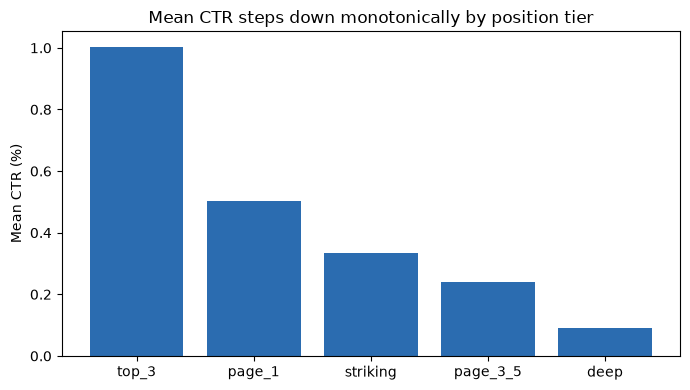

CTR declines from top_3 (1.00%) to deep (0.09%) — a real, monotonic signal, though the
typical page below top_3 still gets zero clicks (see paper §6 for the median caveat).


In [3]:
tier_order = ["top_3", "page_1", "striking", "page_3_5", "deep"]
tier_ctr = queue[queue["position_tier"] != "no_data"].groupby("position_tier")["gsc_ctr_x100"].mean().reindex(tier_order)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tier_ctr.index, tier_ctr.values, color="#2b6cb0")
ax.set_ylabel("Mean CTR (%)")
ax.set_title("Mean CTR steps down monotonically by position tier")
plt.tight_layout()
plt.savefig("../figures/ctr_by_position_tier.png", dpi=150)
plt.show()
print("CTR declines from top_3 (1.00%) to deep (0.09%) — a real, monotonic signal, though the\n"
      "typical page below top_3 still gets zero clicks (see paper §6 for the median caveat).")

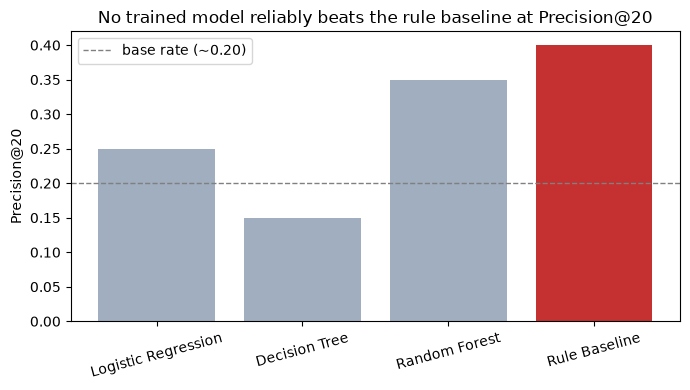

The rule baseline (red) leads every trained model on precision@20, the metric that
matters most for a top-down editor queue.


In [4]:
results_summary = pd.DataFrame({
    "Logistic Regression": [0.558, 0.25, 0.15],
    "Decision Tree": [0.660, 0.15, 0.73],
    "Random Forest": [0.651, 0.35, 0.33],
    "Rule Baseline": [0.601, 0.40, 0.43],
}, index=["AUC", "Precision@20", "Precision@100"]).T

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_summary))
ax.bar(x, results_summary["Precision@20"], color=["#a0aec0","#a0aec0","#a0aec0","#c53030"])
ax.set_xticks(x)
ax.set_xticklabels(results_summary.index, rotation=15)
ax.set_ylabel("Precision@20")
ax.axhline(0.20, color="gray", linestyle="--", linewidth=1, label="base rate (~0.20)")
ax.set_title("No trained model reliably beats the rule baseline at Precision@20")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/model_vs_baseline_p20.png", dpi=150)
plt.show()
print("The rule baseline (red) leads every trained model on precision@20, the metric that\n"
      "matters most for a top-down editor queue.")

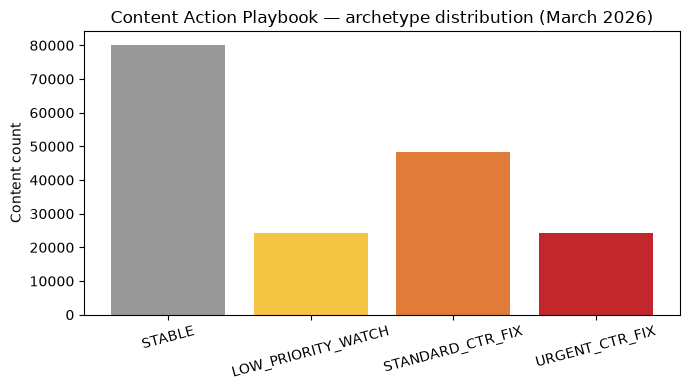

24,152 pages (13.7%) are
flagged URGENT — the highest-priority slice of the full 176,738-page portfolio.


In [5]:
order = ["STABLE", "LOW_PRIORITY_WATCH", "STANDARD_CTR_FIX", "URGENT_CTR_FIX"]
counts = queue["archetype"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=["#999999", "#f4c542", "#e07b39", "#c1272d"])
ax.set_ylabel("Content count")
ax.set_title("Content Action Playbook — archetype distribution (March 2026)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../figures/archetype_distribution.png", dpi=150)
plt.show()
print(f"{counts['URGENT_CTR_FIX']:,} pages ({counts['URGENT_CTR_FIX']/len(queue):.1%}) are\n"
      f"flagged URGENT — the highest-priority slice of the full {len(queue):,}-page portfolio.")

In [6]:
results_summary.round(3).to_json("../outputs/results_table.json", orient="index", indent=2)
print("saved: work/outputs/results_table.json")
display(results_summary)

saved: work/outputs/results_table.json


,AUC,Precision@20,Precision@100
Logistic Regression,0.558,0.25,0.15
Decision Tree,0.660,0.15,0.73
Random Forest,0.651,0.35,0.33
Rule Baseline,0.601,0.40,0.43


## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [✅] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [✅] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## Bonus — Demo, Social, and Employer Summaries (ML-12)

### 5-minute demo outline
1. **The problem (30s):** "A content team has thousands of pages and no way to know which ones
   are worth fixing first." Show the archetype distribution chart.
2. **The naive approach fails (60s):** show the CTR-by-position-tier chart; explain why a
   simple "flag low-position pages" rule breaks (median CTR is 0 in most tiers).
3. **The baseline (90s):** walk through the score formula on one real example row — a top_3
   page with high impressions and low CTR — show it landing in URGENT_CTR_FIX.
4. **The honest validation (90s):** show the model-vs-baseline chart; explain the client-
   grouped split and why the naive random split would have lied (+0.20 inflated precision@20).
5. **The playbook (30s):** show the human-review/no-go list; end on "decision-support, not
   automation."

### Social-post cut
"Built a content-prioritization system on FlyRank's 79M-row search-performance warehouse.
The twist: my hand-built rule beat 3 trained ML models (Logistic Regression, Decision Tree,
Random Forest) at the metric that actually matters — precision@20, the top of an editor's
queue. Full validation, leakage audit, and honest limitations in the write-up. [link]"

### 3-sentence employer-facing summary
I built and validated a content-prioritization system on a 79-million-row real search-
performance warehouse, comparing a hand-designed scoring rule against three trained
classifiers under a client-grouped, leakage-audited validation design. The rule-based baseline
proved competitive with or better than every trained model on the metric that mattered most
(precision@20), and I reported that honestly rather than overselling model complexity. The
full pipeline — data contract, signal audit, baseline, model comparison, and a human-reviewed
action playbook — is documented and reproducible end-to-end in the linked repo.